In [1]:
import os
import json
import time
import random

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from PIL import Image, UnidentifiedImageError
from IPython.display import display

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

Mounted at /content/drive


In [10]:
SCRIPT_DIR = os.getcwd()

IMG_HEIGHT = 128
IMG_WIDTH = 128
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BATCH_SIZE = 32

BASELINE_EPOCHS = 20
DEEP_EPOCHS = 25
TRANSFER_HEAD_EPOCHS = 8
TRANSFER_FINE_TUNE_EPOCHS = 8

VALID_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".ppm")

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
def resolve_dataset_paths():
    candidate_roots = [
        "/content/drive/MyDrive/Traffic_Sign",
        os.path.join(SCRIPT_DIR, "Traffic_Sign", "Traffic_Sign"),
        os.path.join(SCRIPT_DIR, "Traffic_Sign"),
    ]

    for root in candidate_roots:
        train_dir = os.path.join(root, "Train")
        test_dir = os.path.join(root, "Test")
        if os.path.isdir(train_dir) and os.path.isdir(test_dir):
            return root, train_dir, test_dir

        train_dir = os.path.join(root, "train")
        test_dir = os.path.join(root, "test")
        if os.path.isdir(train_dir) and os.path.isdir(test_dir):
            return root, train_dir, test_dir

    raise FileNotFoundError(
        f"Could not find dataset root. Checked: {candidate_roots}"
    )

In [14]:
DATASET_ROOT, TRAIN_DIR, TEST_DIR = resolve_dataset_paths()

OUTPUT_DIR = (
    "/content/drive/MyDrive/traffic_sign_outputs"
    if IN_COLAB
    else os.path.join(SCRIPT_DIR, "traffic_sign_outputs}")
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)
print("Output dir:", OUTPUT_DIR)

Dataset root: /content/drive/MyDrive/Traffic_Sign
Train dir: /content/drive/MyDrive/Traffic_Sign/Train
Test dir: /content/drive/MyDrive/Traffic_Sign/Test
Output dir: /content/drive/MyDrive/traffic_sign_outputs


In [15]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False


def build_train_dataframe(train_dir):
    records = []
    invalid_files = []

    class_names = sorted(
        folder for folder in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, folder))
    )

    for class_name in class_names:
        class_path = os.path.join(train_dir, class_name)
        for file_name in os.listdir(class_path):
            if not file_name.lower().endswith(VALID_EXT):
                continue

            file_path = os.path.join(class_path, file_name)
            if is_valid_image(file_path):
                records.append({"filepath": file_path, "label": class_name, "filename": file_name})
            else:
                invalid_files.append(file_path)

    return pd.DataFrame(records), class_names, invalid_files


def build_flat_test_dataframe(test_dir):
    records = []
    invalid_files = []

    for file_name in sorted(os.listdir(test_dir)):
        file_path = os.path.join(test_dir, file_name)
        if not os.path.isfile(file_path):
            continue
        if not file_name.lower().endswith(VALID_EXT):
            continue

        if is_valid_image(file_path):
            records.append({"filepath": file_path, "filename": file_name})
        else:
            invalid_files.append(file_path)

    return pd.DataFrame(records), invalid_files


def plot_class_distribution(counts, title, save_name):
    df = counts.rename_axis("class_name").reset_index(name="count")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="class_name", y="count", palette="viridis")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)


def show_sample_images_from_df(df, samples_per_class=3, max_classes=6):
    selected_classes = sorted(df["label"].unique())[:max_classes]
    plt.figure(figsize=(4 * samples_per_class, 3 * len(selected_classes)))

    plot_idx = 1
    for class_name in selected_classes:
        class_df = df[df["label"] == class_name]
        sample_df = class_df.sample(min(samples_per_class, len(class_df)), random_state=SEED)

        for _, row in sample_df.iterrows():
            img = Image.open(row["filepath"]).convert("RGB")
            plt.subplot(len(selected_classes), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()


def get_callbacks(prefix):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, f"{prefix}_best.keras"),
            monitor="val_accuracy",
            save_best_only=True,
        ),
    ]


def plot_training_history(history, title_prefix, save_name_prefix):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"{save_name_prefix}_history.png")
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)


def evaluate_on_validation(model, generator, class_names, model_name):
    # FIX: Reset generator before evaluate to prevent stale pointer
    generator.reset()
    loss, accuracy = model.evaluate(generator, verbose=1)

    # FIX: Reset again before predict so classes and predictions align
    generator.reset()
    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n{model_name} VALIDATION METRICS")
    print("Loss:", round(loss, 4))
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1:", round(f1, 4))
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "loss": float(loss),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
    }


def predict_flat_test(model, generator, filenames, class_names, model_name):
    generator.reset()
    preds = model.predict(generator, verbose=1)
    pred_ids = np.argmax(preds, axis=1)
    pred_labels = [class_names[i] for i in pred_ids]
    confidences = np.max(preds, axis=1)

    pred_df = pd.DataFrame(
        {
            "filename": filenames,
            "predicted_class": pred_labels,
            "confidence": confidences,
        }
    )
    print(f"\n{model_name} FLAT TEST PREDICTIONS")
    display(pred_df)

    save_path = os.path.join(OUTPUT_DIR, f"{model_name.lower().replace(' ', '_')}_flat_test_predictions.csv")
    pred_df.to_csv(save_path, index=False)
    print("Saved:", save_path)
    return pred_df


## Build DataFrames
This scans images once and skips corrupted files in memory without moving anything.

In [16]:
train_df, class_names, invalid_train_files = build_train_dataframe(TRAIN_DIR)
test_df, invalid_test_files = build_flat_test_dataframe(TEST_DIR)

print("Classes:", class_names)
print("Num classes:", len(class_names))
print("Valid train images:", len(train_df))
print("Invalid train images skipped:", len(invalid_train_files))
print("Flat test images:", len(test_df))
print("Invalid test images skipped:", len(invalid_test_files))

Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Num classes: 4
Valid train images: 15867
Invalid train images skipped: 28
Flat test images: 4
Invalid test images skipped: 0


## Dataset Analysis

Class imbalance summary


,class_name,train_count
0,Caution,2422
1,Instructions,2841
2,No Passing,5362
3,OverSpeed,5242


/tmp/ipykernel_4167/3686833438.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="class_name", y="count", palette="viridis")


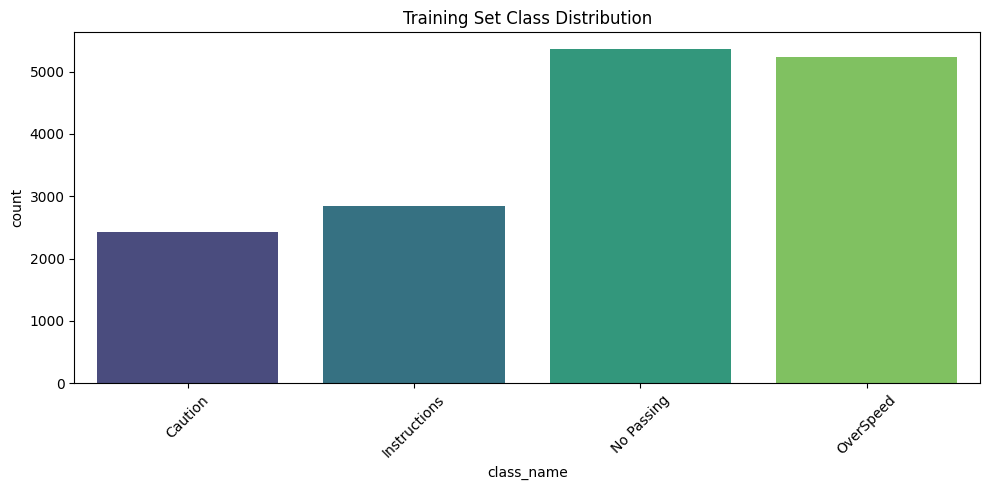

Saved: /content/drive/MyDrive/traffic_sign_outputs/train_class_distribution.png


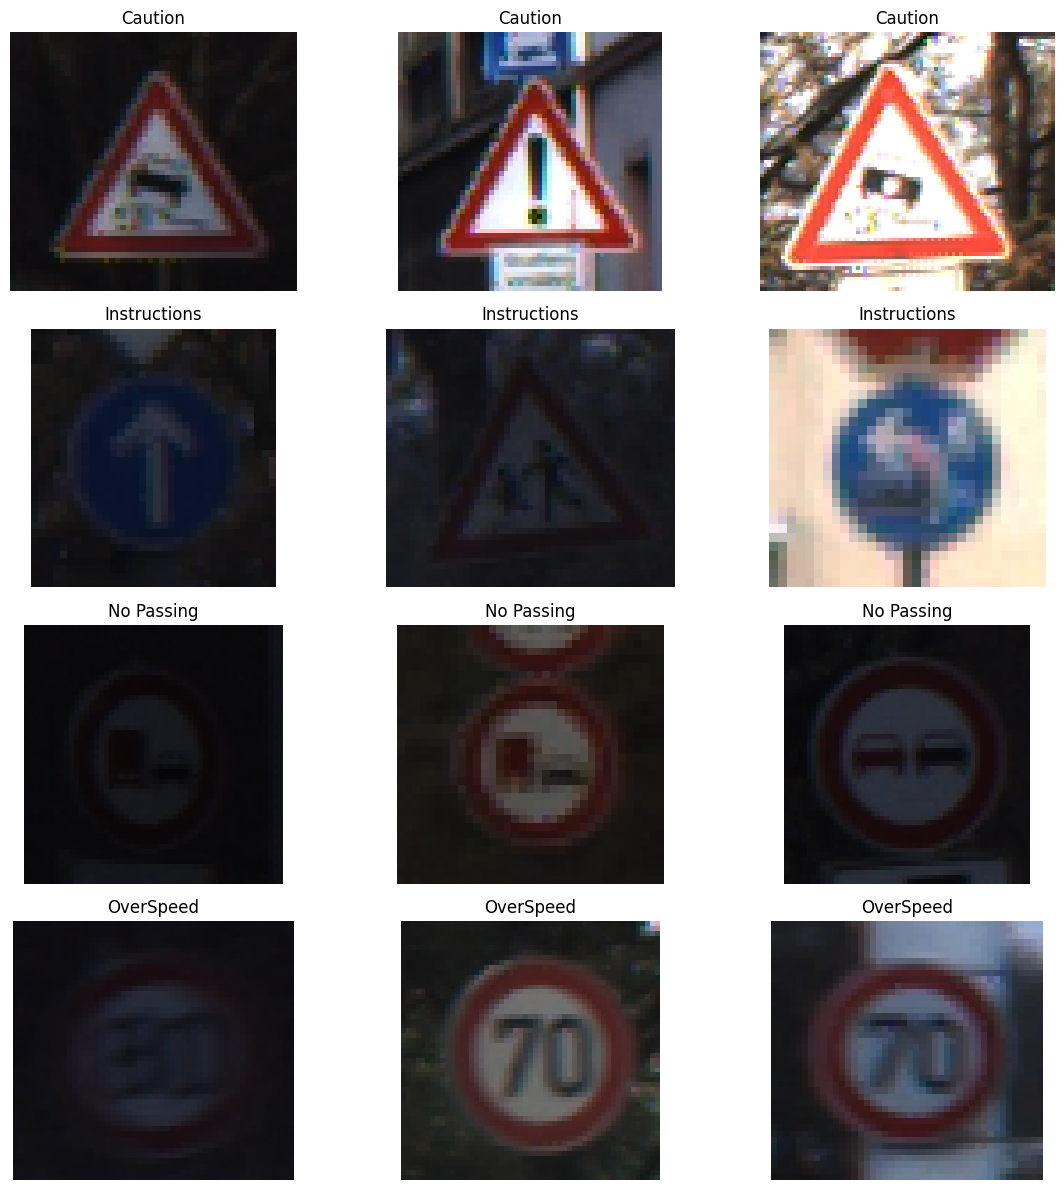

In [17]:
train_counts = train_df["label"].value_counts().sort_index()
distribution_df = train_counts.rename_axis("class_name").reset_index(name="train_count")

print("Class imbalance summary")
display(distribution_df)
plot_class_distribution(train_counts, "Training Set Class Distribution", "train_class_distribution.png")
show_sample_images_from_df(train_df)

## Train/Validation Split and Class Weights

In [18]:
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=SEED,
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=train_split_df["label"].values,
)
class_weights = {i: float(w) for i, w in enumerate(class_weight_values)}

print("Train split:", len(train_split_df))
print("Validation split:", len(val_split_df))
print("Class weights:")
for class_name, weight in zip(class_names, class_weight_values):
    print(class_name, "->", round(float(weight), 4))

Train split: 12693
Validation split: 3174
Class weights:
Caution -> 1.6374
Instructions -> 1.3961
No Passing -> 0.7399
OverSpeed -> 0.7568


## Targeted Augmentation for Imbalanced Classes

Classes below `AUGMENTATION_THRESHOLD` will have synthetic images generated until they reach the target count. Augmented images are saved to a temporary folder and added to the training dataframe.

Median class count : 3233
Augmentation target: 3233 (per minority class)
Threshold          : 2424 (classes below this get augmented)

Minority classes to augment: ['Instructions', 'Caution']

  Instructions: 2273 → target 3233  (generating 960 images)
  Caution: 1938 → target 3233  (generating 1295 images)

Augmentation complete.
Training set size after augmentation: 14948


/tmp/ipykernel_4167/3686833438.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="class_name", y="count", palette="viridis")


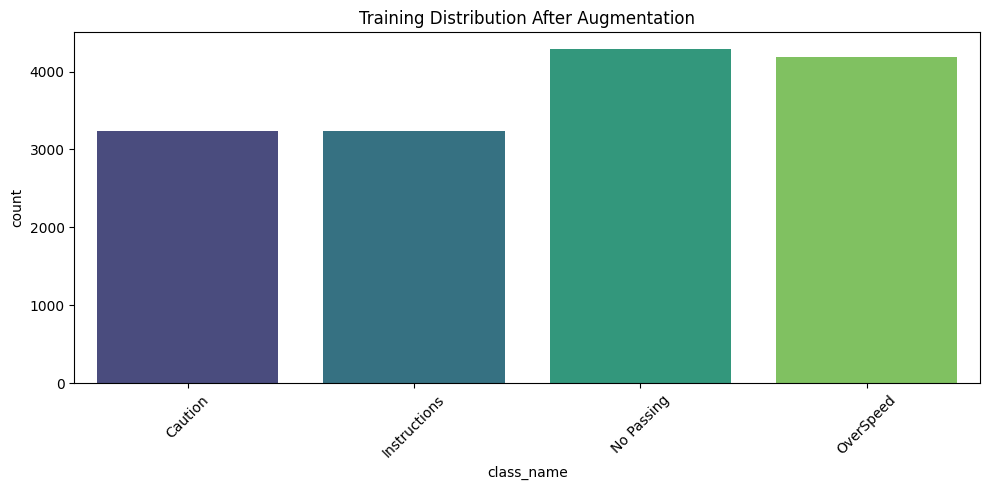

Saved: /content/drive/MyDrive/traffic_sign_outputs/aug_class_distribution.png


In [19]:
# ── Targeted augmentation config ─────────────────────────────────────────────
AUGMENTATION_THRESHOLD = 0.75   # classes below 75% of median count get augmented
TARGET_MULTIPLIER     = 1.0     # augment up to the median count (1× median)
AUG_DIR = os.path.join(OUTPUT_DIR, "augmented_images")
os.makedirs(AUG_DIR, exist_ok=True)

# Aggressive augmentation generator for minority classes
minority_augmenter = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    shear_range=0.15,
    brightness_range=(0.70, 1.30),
    channel_shift_range=20.0,
    horizontal_flip=False,   # traffic signs are NOT horizontally symmetric
    fill_mode="nearest",
)

counts = train_split_df["label"].value_counts()
median_count = int(counts.median())
target_count  = int(median_count * TARGET_MULTIPLIER)
threshold     = int(median_count * AUGMENTATION_THRESHOLD)

print(f"Median class count : {median_count}")
print(f"Augmentation target: {target_count} (per minority class)")
print(f"Threshold          : {threshold} (classes below this get augmented)\n")

minority_classes = counts[counts < threshold].index.tolist()
print(f"Minority classes to augment: {minority_classes}\n")

new_records = []

for cls in minority_classes:
    cls_df = train_split_df[train_split_df["label"] == cls].copy()
    current_count = len(cls_df)
    needed = target_count - current_count
    if needed <= 0:
        continue

    print(f"  {cls}: {current_count} → target {target_count}  (generating {needed} images)")

    cls_aug_dir = os.path.join(AUG_DIR, cls)
    os.makedirs(cls_aug_dir, exist_ok=True)

    generated = 0
    while generated < needed:
        # pick a random source image from this class
        src_row = cls_df.sample(1, random_state=SEED + generated).iloc[0]
        img = Image.open(src_row["filepath"]).convert("RGB").resize(IMAGE_SIZE)
        img_array = np.array(img, dtype=np.float32)[np.newaxis, ...]  # (1, H, W, 3)

        for batch in minority_augmenter.flow(
            img_array,
            batch_size=1,
            save_to_dir=cls_aug_dir,
            save_prefix=f"{cls}_aug",
            save_format="png",
        ):
            generated += 1
            fname = sorted(os.listdir(cls_aug_dir))[-1]  # last saved file
            fpath = os.path.join(cls_aug_dir, fname)
            new_records.append({"filepath": fpath, "label": cls, "filename": fname})
            break  # one image per loop iteration

        if generated >= needed:
            break

print("\nAugmentation complete.")

if new_records:
    aug_df = pd.DataFrame(new_records)
    train_split_df = pd.concat([train_split_df, aug_df], ignore_index=True).sample(
        frac=1, random_state=SEED
    ).reset_index(drop=True)
    print(f"Training set size after augmentation: {len(train_split_df)}")

# Show updated distribution
aug_counts = train_split_df["label"].value_counts().sort_index()
plot_class_distribution(aug_counts, "Training Distribution After Augmentation", "aug_class_distribution.png")


### Visualisation of Augmented Images
Sample augmented images generated for minority classes (Section 2.5.1).

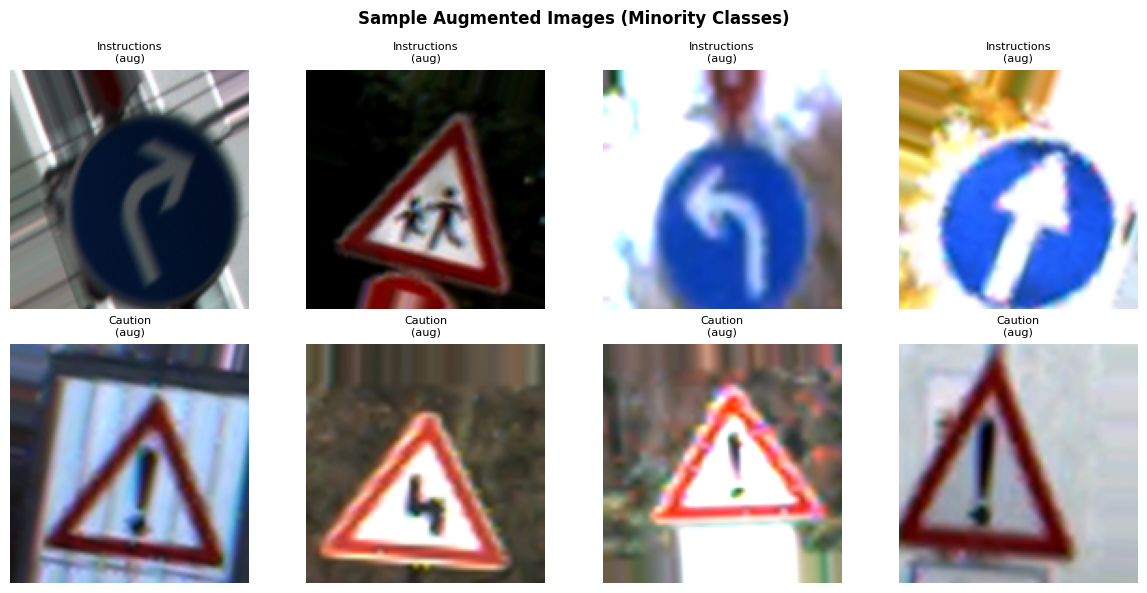

Saved: /content/drive/MyDrive/traffic_sign_outputs/augmented_samples.png


In [20]:
def show_augmented_samples(aug_dir, n=4):
    class_dirs = [d for d in os.listdir(aug_dir)
                  if os.path.isdir(os.path.join(aug_dir, d))][:4]
    if not class_dirs:
        print("No augmented images found.")
        return
    fig, axes = plt.subplots(len(class_dirs), n,
                             figsize=(3 * n, 3 * len(class_dirs)))
    if len(class_dirs) == 1:
        axes = [axes]
    for row_idx, cls in enumerate(class_dirs):
        cls_path = os.path.join(aug_dir, cls)
        files = sorted(os.listdir(cls_path))[:n]
        for col_idx, fname in enumerate(files):
            img = Image.open(os.path.join(cls_path, fname)).convert("RGB")
            axes[row_idx][col_idx].imshow(img)
            axes[row_idx][col_idx].set_title(f"{cls}\n(aug)", fontsize=8)
            axes[row_idx][col_idx].axis("off")
        for col_idx in range(len(files), n):
            axes[row_idx][col_idx].axis("off")
    plt.suptitle("Sample Augmented Images (Minority Classes)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "augmented_samples.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

if os.path.isdir(AUG_DIR) and any(os.scandir(AUG_DIR)):
    show_augmented_samples(AUG_DIR)
else:
    print("All classes are balanced -- augmentation was skipped.")


## Generators

In [21]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    brightness_range=(0.8, 1.2),
    horizontal_flip=False,
    fill_mode="nearest",
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_split_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_split_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col=None,
    target_size=IMAGE_SIZE,
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Flat test samples:", test_generator.samples)

Found 14948 validated image filenames belonging to 4 classes.
Found 3174 validated image filenames belonging to 4 classes.
Found 4 validated image filenames.
Train samples: 14948
Validation samples: 3174
Flat test samples: 4


In [22]:
def build_baseline_model(input_shape, num_classes):
    # FIX: Added Dropout to prevent overfitting / inflated accuracy
    return models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.30),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.50),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(64, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )


def build_deeper_model(input_shape, num_classes, optimizer="adam"):
    model = models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.30),
            layers.Flatten(),
            layers.Dense(512, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.50),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.40),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    opt = keras.optimizers.Adam(learning_rate=1e-3)
    if optimizer == "sgd":
        opt = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def build_transfer_model(num_classes):
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


## Baseline CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 164s 327ms/step - accuracy: 0.7711 - loss: 0.5523 - val_accuracy: 0.9379 - val_loss: 0.1635 - learning_rate: 0.0010
Epoch 2/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 136s 289ms/step - accuracy: 0.9327 - loss: 0.2076 - val_accuracy: 0.9745 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 138s 294ms/step - accuracy: 0.9528 - loss: 0.1416 - val_accuracy: 0.9839 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 4/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 140s 300ms/step - accuracy: 0.9712 - loss: 0.0903 - val_accuracy: 0.9896 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 5/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 142s 303ms/step - accuracy: 0.9740 - loss: 0.0843 - val_accuracy: 0.9915 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 6/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 140s 299ms/step - accuracy: 0.9796 - loss: 0.0652 - val_accuracy: 0.9937 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 7/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 140s 299ms/step - accura

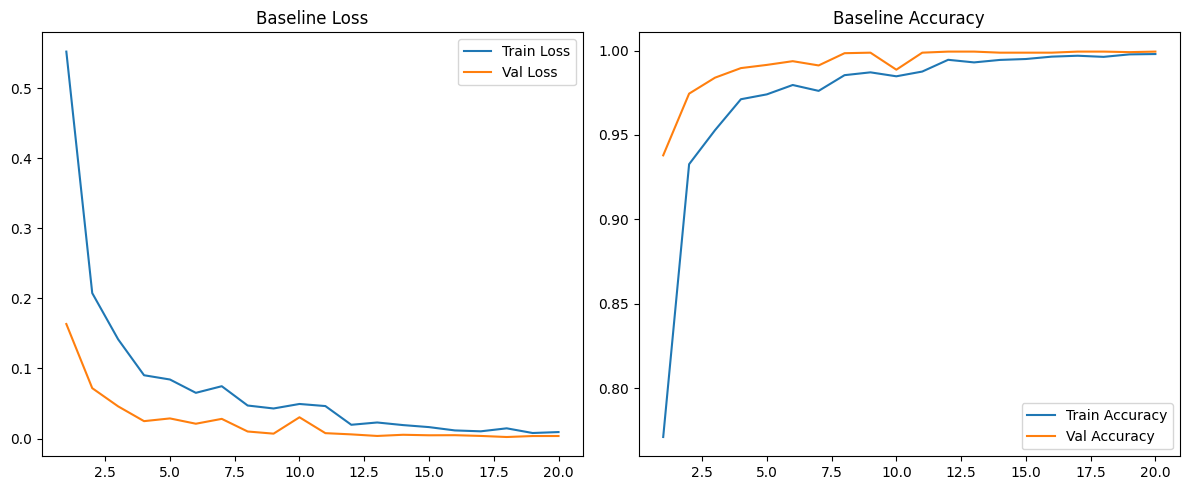

Saved: /content/drive/MyDrive/traffic_sign_outputs/baseline_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9994 - loss: 0.0022
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step

Baseline CNN VALIDATION METRICS
Loss: 0.0022
Accuracy: 0.9994
Precision: 0.9994
Recall: 0.9994
F1: 0.9994

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



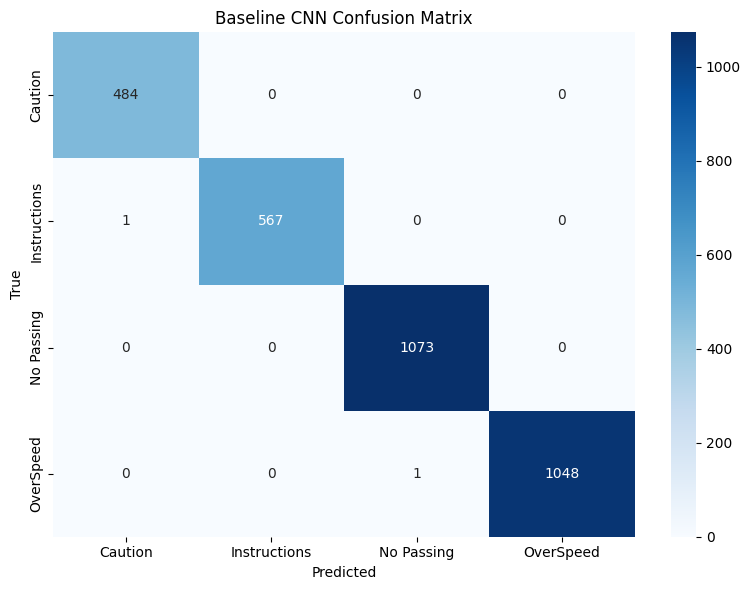

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step

Baseline CNN FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,0.999998
1,00009_00001_00027.png,No Passing,1.000000
2,00018_00000_00001.png,Caution,0.990070
3,00028_00000_00007.png,Instructions,0.999868


Saved: /content/drive/MyDrive/traffic_sign_outputs/baseline_cnn_flat_test_predictions.csv


In [23]:
baseline_model = build_baseline_model(INPUT_SHAPE, len(class_names))
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_model.summary()

start_time = time.time()
baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=BASELINE_EPOCHS,
    callbacks=get_callbacks("baseline"),
    class_weight=class_weights,
    verbose=1,
)
baseline_time = time.time() - start_time

plot_training_history(baseline_history, "Baseline", "baseline")
baseline_metrics = evaluate_on_validation(baseline_model, val_generator, class_names, "Baseline CNN")
baseline_metrics["training_time_seconds"] = baseline_time
baseline_test_preds = predict_flat_test(
    baseline_model,
    test_generator,
    test_df["filename"].tolist(),
    class_names,
    "Baseline CNN",
)

In [24]:
# Save model locally in Colab runtime
baseline_model.save("/content/drive/MyDrive/AI ML/baseline_traffic_sign_model.keras")

## Sample Inference on Validation Images
Visualise per-image predictions with confidence scores (Section 2.5.2).

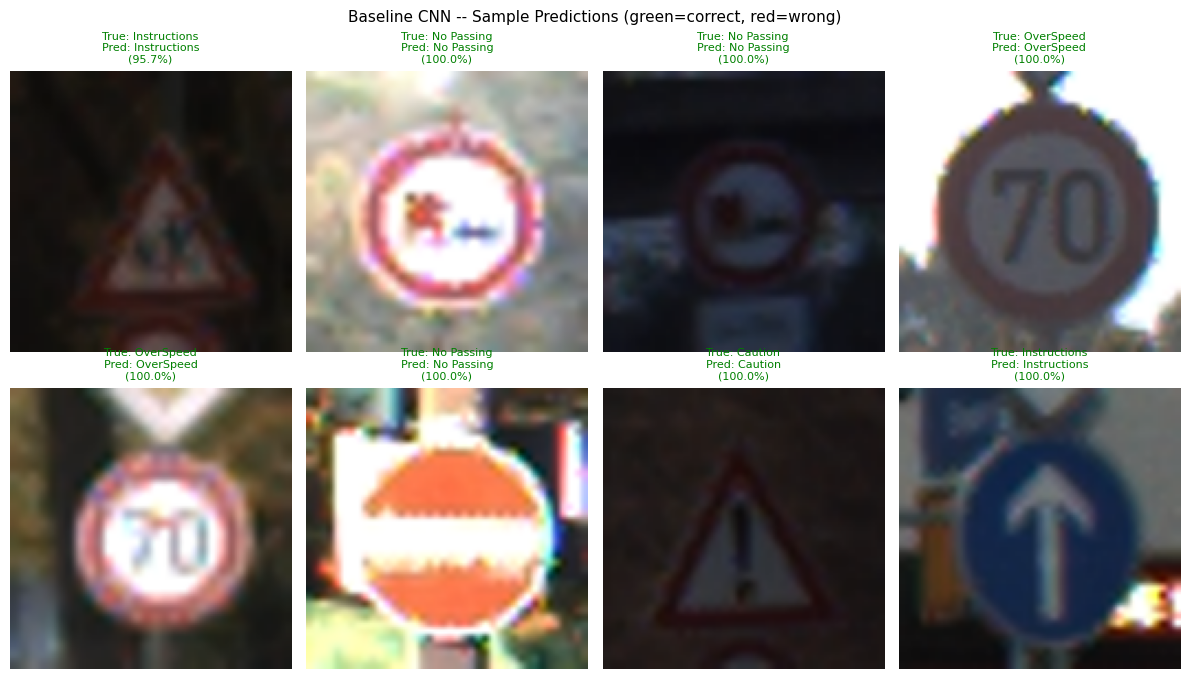

Saved: /content/drive/MyDrive/traffic_sign_outputs/baseline_cnn_sample_preds.png


In [25]:
def plot_sample_predictions(model, val_df, class_names, model_name, n=8):
    sample = val_df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * (n // 2), 7))
    axes = axes.flatten()
    for idx, row in sample.iterrows():
        img_pil = Image.open(row["filepath"]).convert("RGB").resize(IMAGE_SIZE)
        img_arr = np.array(img_pil, dtype=np.float32) / 255.0
        pred = model.predict(img_arr[np.newaxis, ...], verbose=0)
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred)
        true_class = row["label"]
        color = "green" if pred_class == true_class else "red"
        axes[idx].imshow(img_pil)
        axes[idx].set_title(
            f"True: {true_class}\nPred: {pred_class}\n({confidence:.1%})",
            fontsize=8, color=color)
        axes[idx].axis("off")
    plt.suptitle(f"{model_name} -- Sample Predictions (green=correct, red=wrong)",
                 fontsize=11)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR,
        f"{model_name.lower().replace(chr(32), chr(95))}_sample_preds.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

plot_sample_predictions(baseline_model, val_split_df, class_names, "Baseline CNN")


## Deeper CNN with Adam

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           51

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 171s 331ms/step - accuracy: 0.8091 - loss: 0.5044 - val_accuracy: 0.8976 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 142s 304ms/step - accuracy: 0.9434 - loss: 0.1653 - val_accuracy: 0.9537 - val_loss: 0.1546 - learning_rate: 0.0010
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 149s 317ms/step - accuracy: 0.9654 - loss: 0.1023 - val_accuracy: 0.9902 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 145s 310ms/step - accuracy: 0.9767 - loss: 0.0708 - val_accuracy: 0.9978 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 144s 306ms/step - accuracy: 0.9829 - loss: 0.0568 - val_accuracy: 0.9975 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 149s 318ms/step - accuracy: 0.9784 - loss: 0.0683 - val_accuracy: 0.9247 - val_loss: 0.1939 - learning_rate: 0.0010
Epoch 7/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy

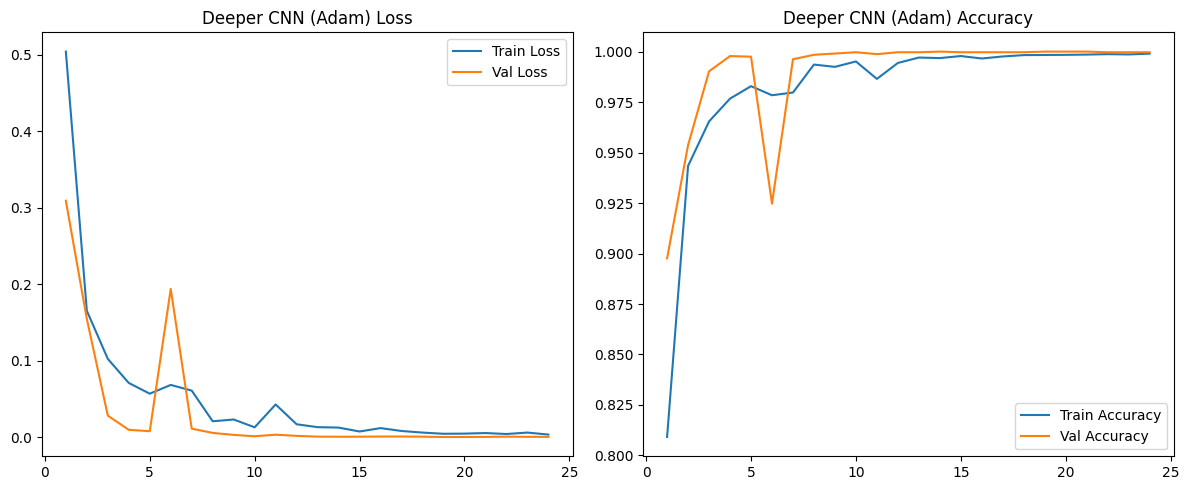

Saved: /content/drive/MyDrive/traffic_sign_outputs/deeper_adam_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 1.0000 - loss: 1.0562e-04
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step

Deeper CNN (Adam) VALIDATION METRICS
Loss: 0.0001
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



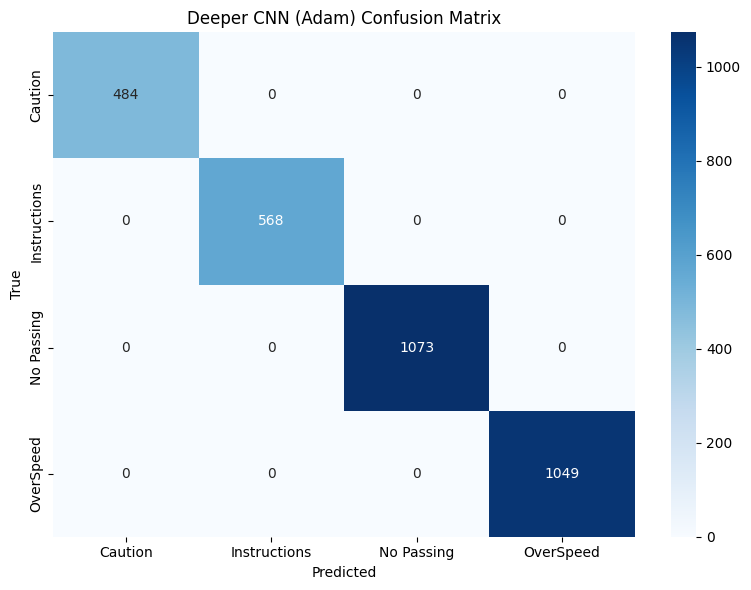

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step

Deeper CNN Adam FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,1.000000
1,00009_00001_00027.png,No Passing,1.000000
2,00018_00000_00001.png,Caution,0.999957
3,00028_00000_00007.png,Instructions,0.999320


Saved: /content/drive/MyDrive/traffic_sign_outputs/deeper_cnn_adam_flat_test_predictions.csv


In [26]:
deeper_model = build_deeper_model(INPUT_SHAPE, len(class_names), optimizer="adam")
deeper_model.summary()

start_time = time.time()
deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=get_callbacks("deeper_adam"),
    class_weight=class_weights,
    verbose=1,
)
deeper_time = time.time() - start_time

plot_training_history(deeper_history, "Deeper CNN (Adam)", "deeper_adam")
deeper_metrics = evaluate_on_validation(deeper_model, val_generator, class_names, "Deeper CNN (Adam)")
deeper_metrics["training_time_seconds"] = deeper_time
deeper_test_preds = predict_flat_test(
    deeper_model,
    test_generator,
    test_df["filename"].tolist(),
    class_names,
    "Deeper CNN Adam",
)

In [27]:
deeper_model.save("/content/drive/MyDrive/AI ML/deeper_cnn_model.keras")

## 2.5.3 Observations: Deeper Model vs Baseline

**Architecture changes:** 6 Conv layers (3 paired blocks) vs 3 in baseline. BatchNormalization added after each block. Dense widths increased to 512→256→128.

**Expected improvements:**
- Greater depth extracts richer, more abstract features (edges → textures → sign shapes).
- BatchNormalization stabilises gradients and accelerates convergence.
- Dropout (0.25–0.50) prevents increased capacity from causing overfitting.

**Trade-offs:**
- Training time increases roughly 2–3x due to the larger parameter count.
- On small datasets, diminishing returns may limit the improvement over the baseline.
- The final comparison table quantifies accuracy, F1, and training time differences.

## Deeper CNN with SGD
Same architecture, different optimiser. Required for **Section 2.5.4 Optimizer Analysis**.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           51

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 159s 319ms/step - accuracy: 0.7721 - loss: 0.5658 - val_accuracy: 0.8308 - val_loss: 0.4323 - learning_rate: 0.0100
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 148s 315ms/step - accuracy: 0.9092 - loss: 0.2647 - val_accuracy: 0.9282 - val_loss: 0.1707 - learning_rate: 0.0100
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 145s 309ms/step - accuracy: 0.9339 - loss: 0.1940 - val_accuracy: 0.9622 - val_loss: 0.0949 - learning_rate: 0.0100
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 144s 307ms/step - accuracy: 0.9459 - loss: 0.1716 - val_accuracy: 0.9726 - val_loss: 0.0778 - learning_rate: 0.0100
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 145s 309ms/step - accuracy: 0.9598 - loss: 0.1257 - val_accuracy: 0.9732 - val_loss: 0.0669 - learning_rate: 0.0100
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - accuracy: 0.9667 - loss: 0.1078 - val_accuracy: 0.8790 - val_loss: 0.3568 - learning_rate: 0.0100
Epoch 7/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 142s 303ms/step - accura

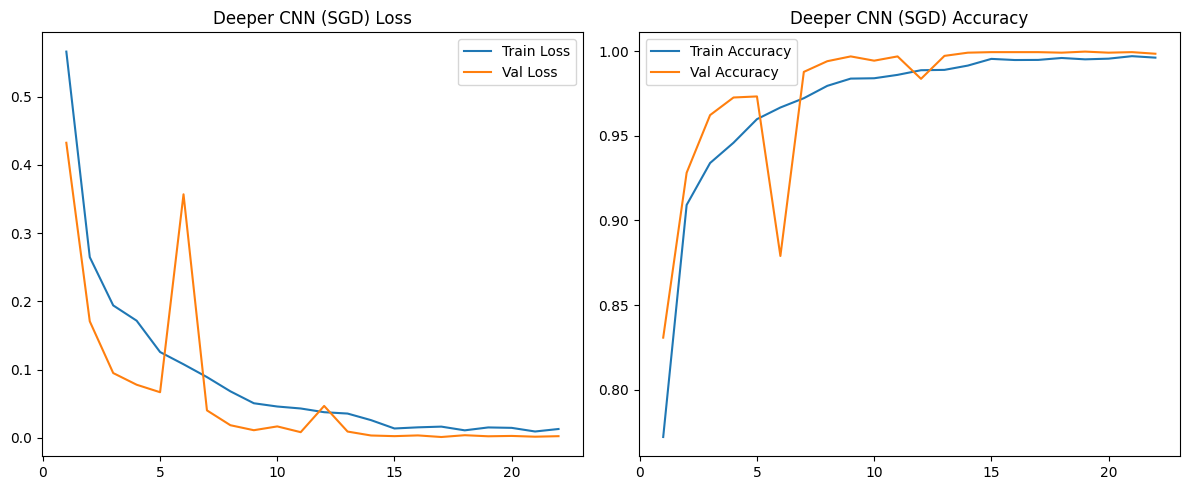

Saved: /content/drive/MyDrive/traffic_sign_outputs/deeper_sgd_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9994 - loss: 0.0013   
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step

Deeper CNN (SGD) VALIDATION METRICS
Loss: 0.0013
Accuracy: 0.9994
Precision: 0.9994
Recall: 0.9994
F1: 0.9994

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



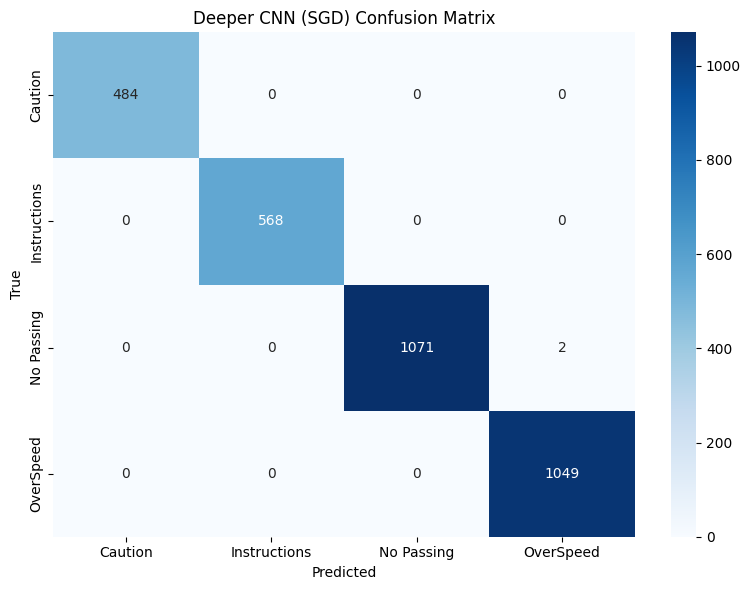

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step

Deeper CNN SGD FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,1.000000
1,00009_00001_00027.png,No Passing,0.999995
2,00018_00000_00001.png,Caution,0.999975
3,00028_00000_00007.png,Instructions,0.999978


Saved: /content/drive/MyDrive/traffic_sign_outputs/deeper_cnn_sgd_flat_test_predictions.csv


In [28]:
deeper_sgd_model = build_deeper_model(INPUT_SHAPE, len(class_names), optimizer="sgd")
deeper_sgd_model.summary()

start_time = time.time()
deeper_sgd_history = deeper_sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=get_callbacks("deeper_sgd"),
    class_weight=class_weights,
    verbose=1,
)
deeper_sgd_time = time.time() - start_time

plot_training_history(deeper_sgd_history, "Deeper CNN (SGD)", "deeper_sgd")
deeper_sgd_metrics = evaluate_on_validation(
    deeper_sgd_model, val_generator, class_names, "Deeper CNN (SGD)")
deeper_sgd_metrics["training_time_seconds"] = deeper_sgd_time
deeper_sgd_test_preds = predict_flat_test(
    deeper_sgd_model, test_generator,
    test_df["filename"].tolist(), class_names, "Deeper CNN SGD")


In [29]:
deeper_sgd_model.save("/content/drive/MyDrive/AI ML/deeper_cnn_sgd_model.keras")

In [30]:
def compare_histories(history_baseline, history_deeper):
    base = history_baseline.history
    deep = history_deeper.history

    epochs_base = range(1, len(base["accuracy"]) + 1)
    epochs_deep = range(1, len(deep["accuracy"]) + 1)

    # Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_base, base["accuracy"], label="Baseline Train Accuracy")
    plt.plot(epochs_base, base["val_accuracy"], label="Baseline Val Accuracy")
    plt.plot(epochs_deep, deep["accuracy"], label="Deeper Train Accuracy")
    plt.plot(epochs_deep, deep["val_accuracy"], label="Deeper Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Baseline vs Deeper Architecture - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_base, base["loss"], label="Baseline Train Loss")
    plt.plot(epochs_base, base["val_loss"], label="Baseline Val Loss")
    plt.plot(epochs_deep, deep["loss"], label="Deeper Train Loss")
    plt.plot(epochs_deep, deep["val_loss"], label="Deeper Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Baseline vs Deeper Architecture - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

### Optimizer Comparison: Adam vs SGD
Side-by-side convergence curves (Section 2.5.4).

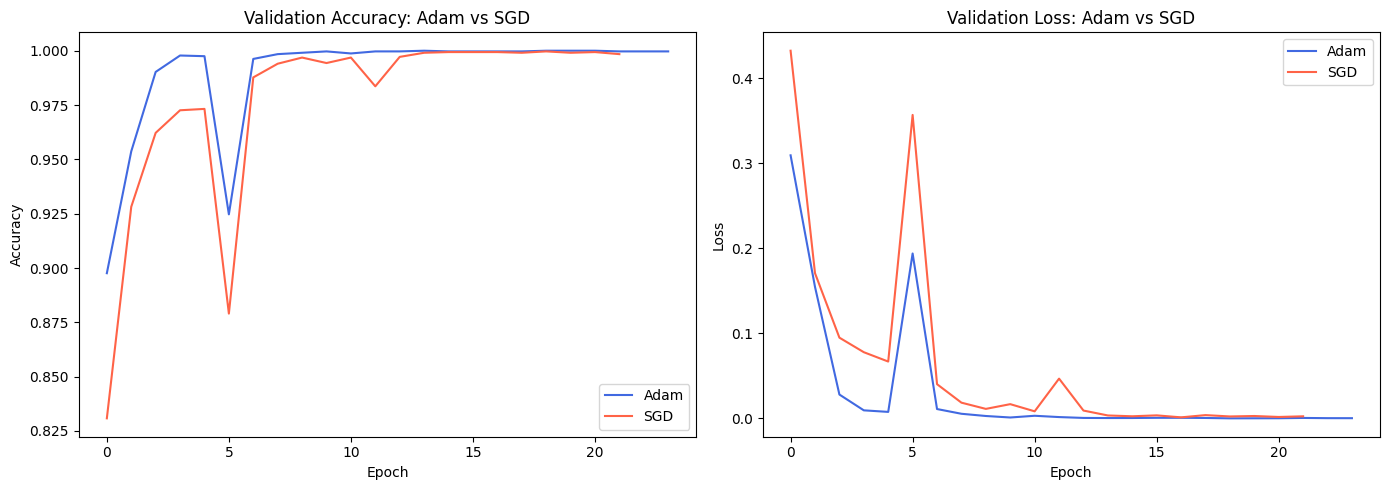

Saved: /content/drive/MyDrive/traffic_sign_outputs/optimizer_comparison.png
Adam -- Accuracy: 1.0000  F1: 1.0000  Time: 3451s
SGD  -- Accuracy: 0.9994  F1: 0.9994  Time: 3236s


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label, color in [
    (deeper_history.history,     "Adam", "royalblue"),
    (deeper_sgd_history.history, "SGD",  "tomato"),
]:
    axes[0].plot(hist["val_accuracy"], label=label, color=color)
    axes[1].plot(hist["val_loss"],     label=label, color=color)
axes[0].set_title("Validation Accuracy: Adam vs SGD")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()
axes[1].set_title("Validation Loss: Adam vs SGD")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss");     axes[1].legend()
plt.tight_layout()
opt_cmp_path = os.path.join(OUTPUT_DIR, "optimizer_comparison.png")
plt.savefig(opt_cmp_path, dpi=200); plt.show()
print("Saved:", opt_cmp_path)

print("Adam -- Accuracy: {:.4f}  F1: {:.4f}  Time: {:.0f}s".format(
    deeper_metrics["accuracy"], deeper_metrics["f1_score"],
    deeper_metrics["training_time_seconds"]))
print("SGD  -- Accuracy: {:.4f}  F1: {:.4f}  Time: {:.0f}s".format(
    deeper_sgd_metrics["accuracy"], deeper_sgd_metrics["f1_score"],
    deeper_sgd_metrics["training_time_seconds"]))


## Ablation Study -- Removing Dropout
We remove all Dropout layers from the deeper model to measure their contribution to regularisation (Section 2.5.4).

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,232,420 (65.74 MB)

 Trainable params: 17,230,948 (65.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 164s 337ms/step - accuracy: 0.9063 - loss: 0.2633 - val_accuracy: 0.7536 - val_loss: 0.5746 - learning_rate: 0.0010
Epoch 2/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - accuracy: 0.9732 - loss: 0.0760 - val_accuracy: 0.9704 - val_loss: 0.0851 - learning_rate: 0.0010
Epoch 3/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 146s 313ms/step - accuracy: 0.9868 - loss: 0.0404 - val_accuracy: 0.9953 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 4/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 143s 304ms/step - accuracy: 0.9909 - loss: 0.0285 - val_accuracy: 0.9827 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 5/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 140s 299ms/step - accuracy: 0.9909 - loss: 0.0278 - val_accuracy: 0.9975 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 6/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 145s 310ms/step - accuracy: 0.9892 - loss: 0.0348 - val_accuracy: 0.9902 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 7/25
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy

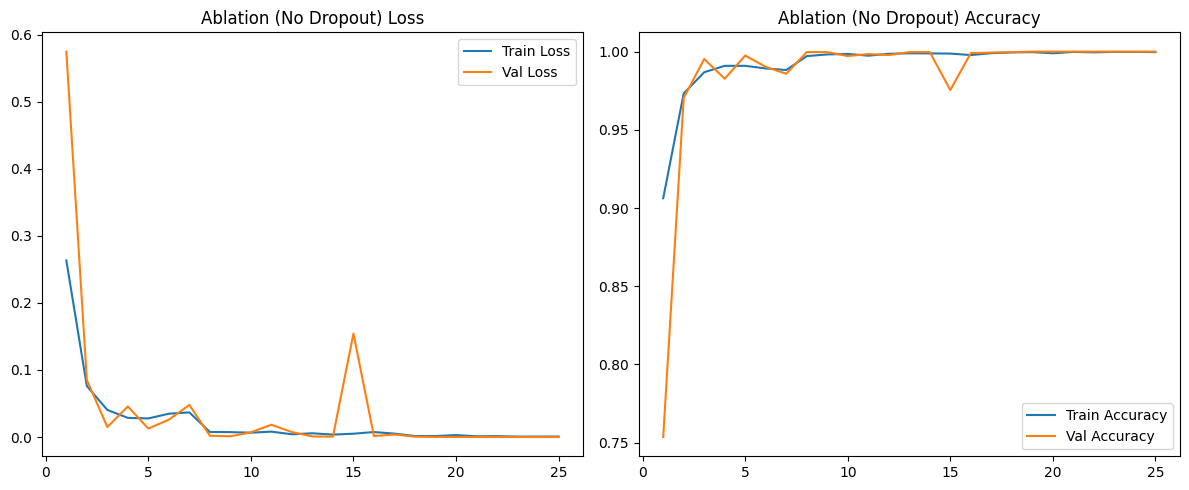

Saved: /content/drive/MyDrive/traffic_sign_outputs/ablation_no_dropout_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 1.0000 - loss: 4.9308e-05
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step

Ablation (No Dropout) VALIDATION METRICS
Loss: 0.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Classification Report
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



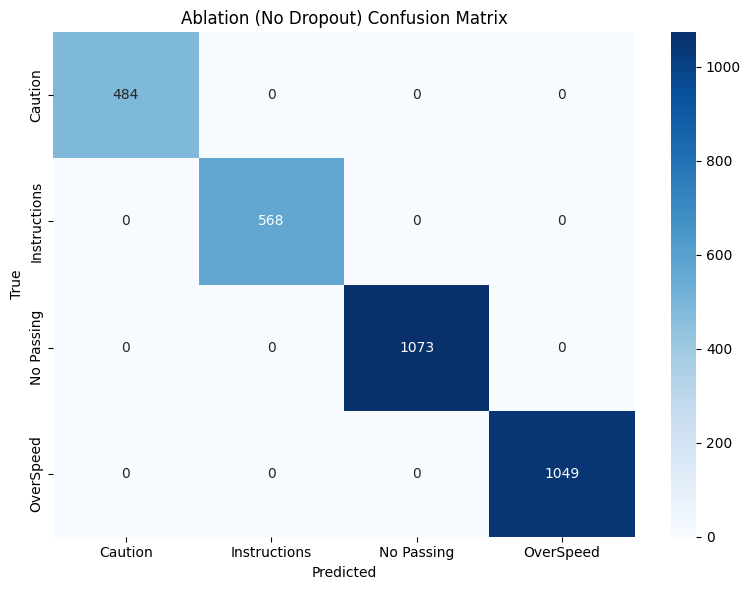


-- Ablation Summary --
Full Deeper (with Dropout) -- Accuracy: 1.0000  F1: 1.0000
No-Dropout Ablation        -- Accuracy: 1.0000  F1: 1.0000
Train-val accuracy gap  -- With Dropout: -0.0007  |  No Dropout: -0.0003
A larger gap without Dropout confirms Dropout reduces overfitting.


In [32]:
def build_no_dropout_model(input_shape, num_classes):
    """Deeper model with Dropout removed -- ablation study."""
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32,  (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32,  (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Dropout removed
        layers.Conv2D(64,  (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64,  (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Dropout removed
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Dropout removed
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        # Dropout removed
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


ablation_model = build_no_dropout_model(INPUT_SHAPE, len(class_names))
ablation_model.summary()

start_time = time.time()
ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=DEEP_EPOCHS,
    callbacks=get_callbacks("ablation_no_dropout"),
    class_weight=class_weights,
    verbose=1,
)
ablation_time = time.time() - start_time

plot_training_history(ablation_history, "Ablation (No Dropout)", "ablation_no_dropout")
ablation_metrics = evaluate_on_validation(
    ablation_model, val_generator, class_names, "Ablation (No Dropout)")
ablation_metrics["training_time_seconds"] = ablation_time

print("\n-- Ablation Summary --")
print("Full Deeper (with Dropout) -- Accuracy: {:.4f}  F1: {:.4f}".format(
    deeper_metrics["accuracy"], deeper_metrics["f1_score"]))
print("No-Dropout Ablation        -- Accuracy: {:.4f}  F1: {:.4f}".format(
    ablation_metrics["accuracy"], ablation_metrics["f1_score"]))

d_gap = deeper_history.history["accuracy"][-1] - deeper_history.history["val_accuracy"][-1]
a_gap = ablation_history.history["accuracy"][-1] - ablation_history.history["val_accuracy"][-1]
print(f"Train-val accuracy gap  -- With Dropout: {d_gap:.4f}  |  No Dropout: {a_gap:.4f}")
print("A larger gap without Dropout confirms Dropout reduces overfitting.")


In [33]:
ablation_time = time.time() - start_time

ablation_model.save("/content/drive/MyDrive/AI ML/ablation_no_dropout_model.keras")

## Transfer Learning

Found 14948 validated image filenames belonging to 4 classes.
Found 3174 validated image filenames belonging to 4 classes.
Found 4 validated image filenames.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 319s 635ms/step - accuracy: 0.9080 - loss: 0.2451 - val_accuracy: 0.9294 - val_loss: 0.1861 - learning_rate: 0.0010
Epoch 2/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 273s 582ms/step - accuracy: 0.9497 - loss: 0.1402 - val_accuracy: 0.9360 - val_loss: 0.1591 - learning_rate: 0.0010
Epoch 3/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 283s 604ms/step - accuracy: 0.9556 - loss: 0.1190 - val_accuracy: 0.9480 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 4/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 293s 626ms/step - accuracy: 0.9655 - loss: 0.0927 - val_accuracy: 0.9534 - val_loss: 0.1186 - learning_rate: 0.0010
Epoch 5/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 276s 591ms/step - accuracy: 0.9680 - loss: 0.0821 - val_accuracy: 0.9669 - val_loss: 0.0886 - learning_rate: 0.0010
Epoch 6/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 267s 569ms/step - accuracy: 0.9693 - loss: 0.0810 - val_accuracy: 0.9688 - val_loss: 0.0912 - learning_rate: 0.0010
Epoch 7/8
468/468 ━━━━━━━━━━━━━━━━━━━━ 265s 567ms/step - accuracy: 0.9

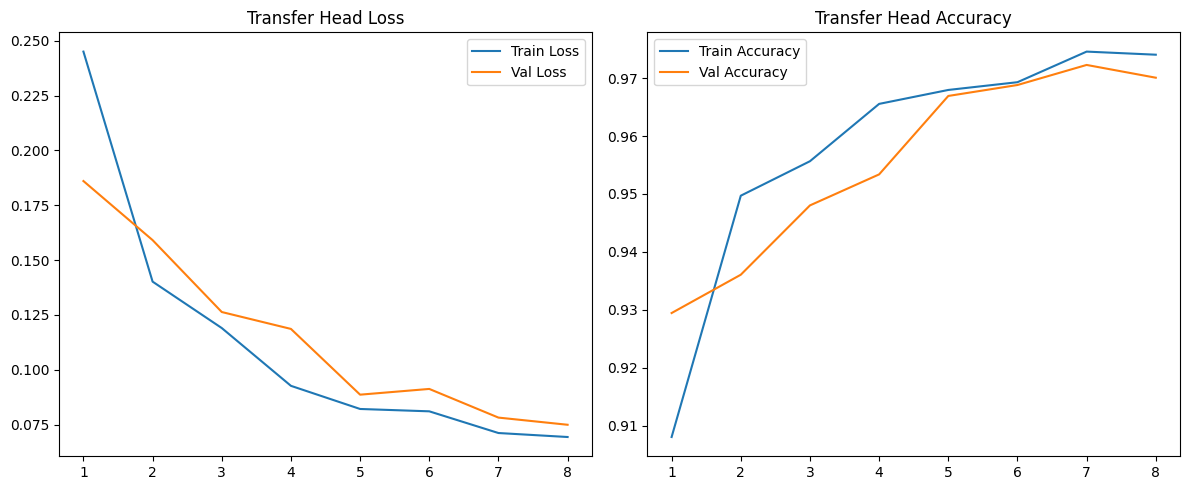

Saved: /content/drive/MyDrive/traffic_sign_outputs/transfer_head_history.png


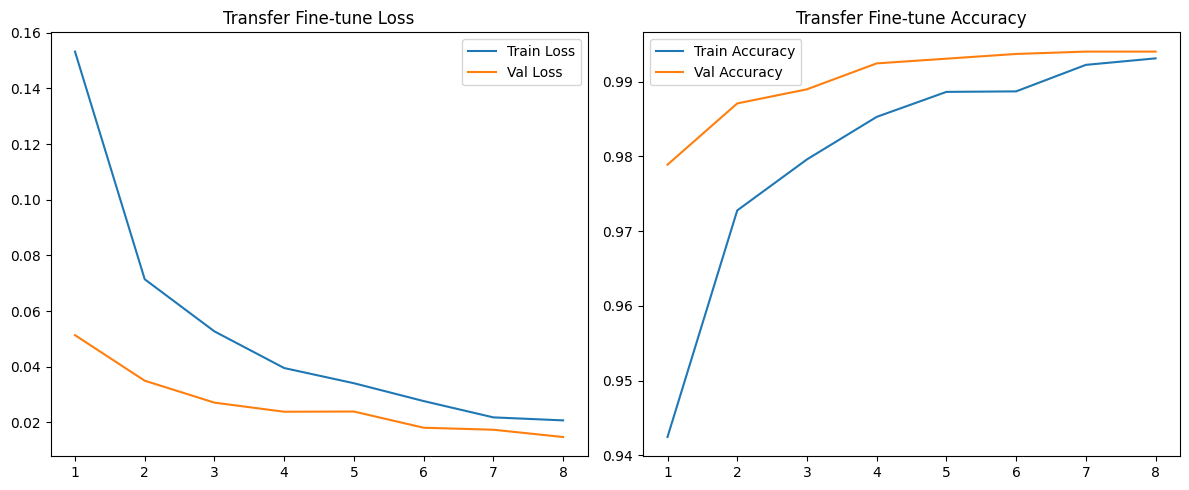

Saved: /content/drive/MyDrive/traffic_sign_outputs/transfer_finetune_history.png
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.9940 - loss: 0.0148
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step

Transfer Learning VALIDATION METRICS
Loss: 0.0148
Accuracy: 0.994
Precision: 0.994
Recall: 0.994
F1: 0.994

Classification Report
              precision    recall  f1-score   support

     Caution       0.99      1.00      0.99       484
Instructions       1.00      0.99      0.99       568
  No Passing       1.00      0.99      0.99      1073
   OverSpeed       0.99      1.00      0.99      1049

    accuracy                           0.99      3174
   macro avg       0.99      0.99      0.99      3174
weighted avg       0.99      0.99      0.99      3174



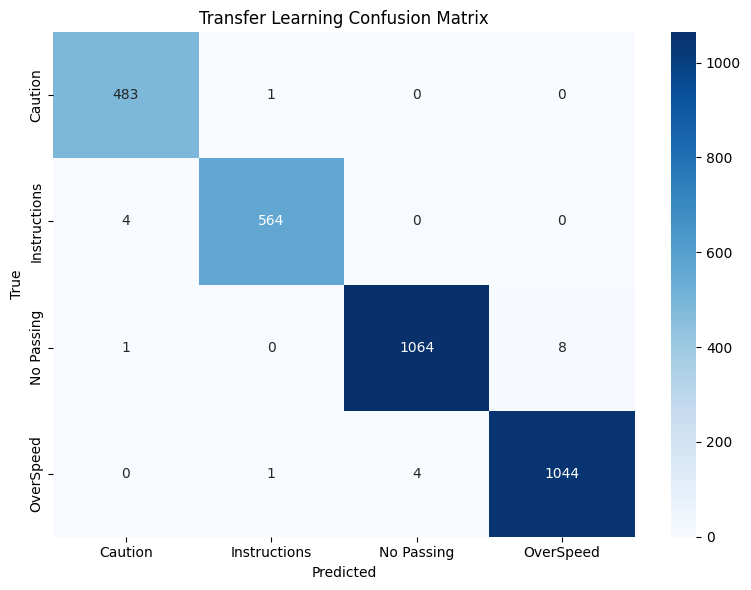

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Transfer Learning FLAT TEST PREDICTIONS


,filename,predicted_class,confidence
0,00003_00000_00001.png,OverSpeed,0.999725
1,00009_00001_00027.png,No Passing,0.999992
2,00018_00000_00001.png,Caution,0.997274
3,00028_00000_00007.png,Instructions,0.796759


Saved: /content/drive/MyDrive/traffic_sign_outputs/transfer_learning_flat_test_predictions.csv


In [34]:
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest",
)
tl_eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

tl_train_generator = tl_train_datagen.flow_from_dataframe(
    dataframe=train_split_df,
    x_col="filepath",
    y_col="label",
    target_size=(224, 224),
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
tl_val_generator = tl_eval_datagen.flow_from_dataframe(
    dataframe=val_split_df,
    x_col="filepath",
    y_col="label",
    target_size=(224, 224),
    class_mode="categorical",
    classes=class_names,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
tl_test_generator = tl_eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col=None,
    target_size=(224, 224),
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

transfer_model, transfer_base = build_transfer_model(len(class_names))
transfer_model.summary()

start_time = time.time()
transfer_head_history = transfer_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=TRANSFER_HEAD_EPOCHS,
    callbacks=get_callbacks("transfer_head"),
    class_weight=class_weights,
    verbose=1,
)

transfer_base.trainable = True
for layer in transfer_base.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_finetune_history = transfer_model.fit(
    tl_train_generator,
    validation_data=tl_val_generator,
    epochs=TRANSFER_FINE_TUNE_EPOCHS,
    callbacks=get_callbacks("transfer_finetune"),
    class_weight=class_weights,
    verbose=1,
)
transfer_time = time.time() - start_time

plot_training_history(transfer_head_history, "Transfer Head", "transfer_head")
plot_training_history(transfer_finetune_history, "Transfer Fine-tune", "transfer_finetune")
transfer_metrics = evaluate_on_validation(transfer_model, tl_val_generator, class_names, "Transfer Learning")
transfer_metrics["training_time_seconds"] = transfer_time
transfer_test_preds = predict_flat_test(
    transfer_model,
    tl_test_generator,
    test_df["filename"].tolist(),
    class_names,
    "Transfer Learning",
)

In [40]:
import os

# Save entire trained model
model_path = "/content/drive/MyDrive/AI Ml folder/transfer_learning_model.keras"
save_dir = os.path.dirname(model_path)
os.makedirs(save_dir, exist_ok=True)
transfer_model.save(model_path)

## Comparison and Summary

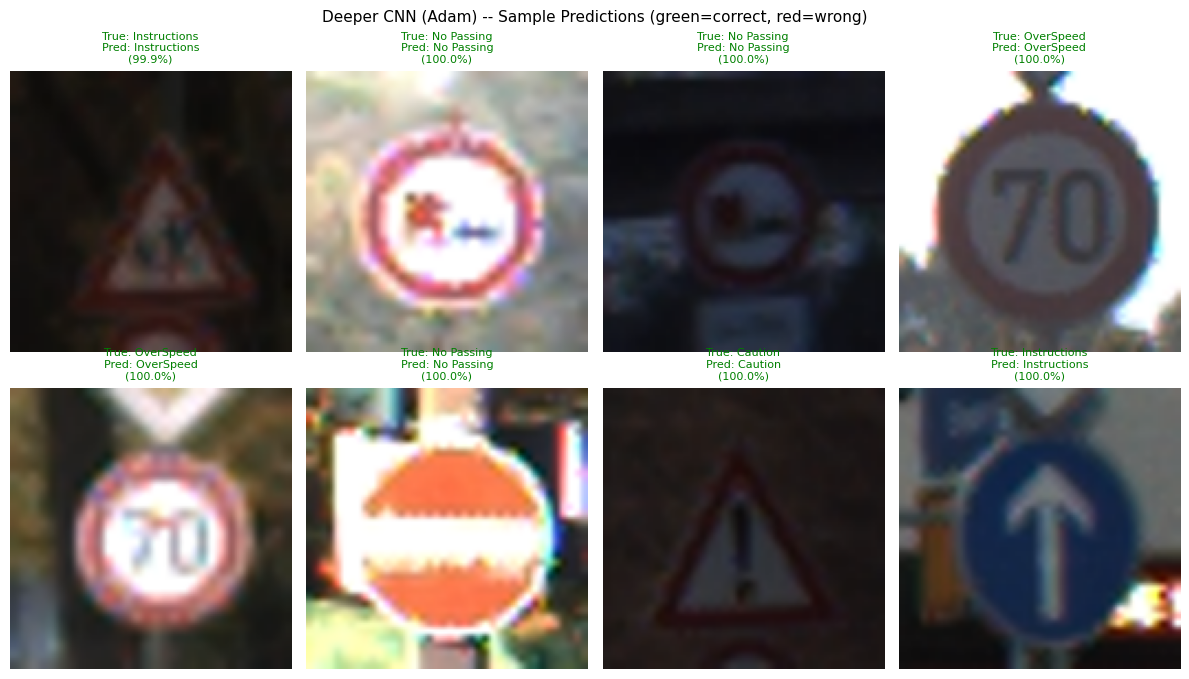

Saved: /content/drive/MyDrive/traffic_sign_outputs/deeper_cnn_(adam)_sample_preds.png


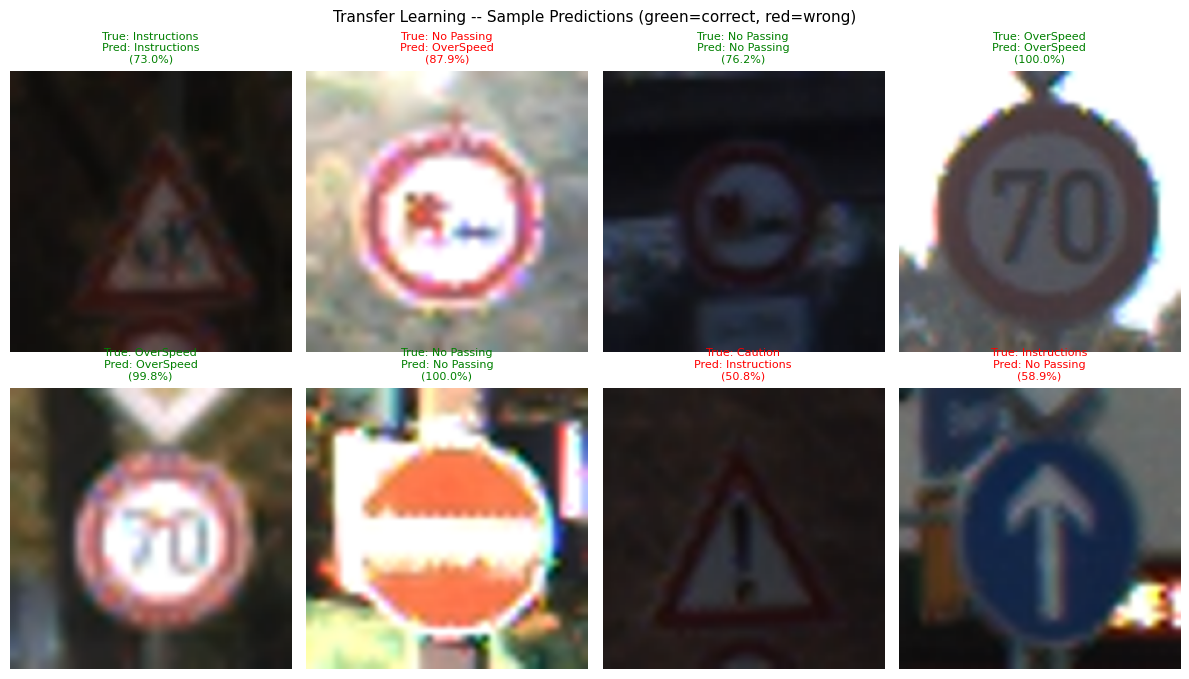

Saved: /content/drive/MyDrive/traffic_sign_outputs/transfer_learning_sample_preds.png


In [39]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

def plot_sample_predictions(model, val_df, class_names, model_name, n=8, target_image_size=IMAGE_SIZE):
    sample = val_df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * (n // 2), 7))
    axes = axes.flatten()
    for idx, row in sample.iterrows():
        img_pil = Image.open(row["filepath"]).convert("RGB").resize(target_image_size)
        img_arr = np.array(img_pil, dtype=np.float32) / 255.0
        pred = model.predict(img_arr[np.newaxis, ...], verbose=0)
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred)
        true_class = row["label"]
        color = "green" if pred_class == true_class else "red"
        axes[idx].imshow(img_pil)
        axes[idx].set_title(
            f"True: {true_class}\nPred: {pred_class}\n({confidence:.1%})",
            fontsize=8, color=color)
        axes[idx].axis("off")
    plt.suptitle(f"{model_name} -- Sample Predictions (green=correct, red=wrong)",
                 fontsize=11)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR,
        f"{model_name.lower().replace(chr(32), chr(95))}_sample_preds.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Saved:", save_path)

plot_sample_predictions(deeper_model, val_split_df, class_names, "Deeper CNN (Adam)", target_image_size=IMAGE_SIZE)
plot_sample_predictions(transfer_model, val_split_df, class_names, "Transfer Learning", target_image_size=(224, 224))

,Model,Loss,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Baseline CNN,0.0022,0.9994,0.9994,0.9994,0.9994,2758.2542
1,Deeper CNN (Adam),0.0001,1.0000,1.0000,1.0000,1.0000,3450.7226
2,Deeper CNN (SGD),0.0013,0.9994,0.9994,0.9994,0.9994,3235.7465
3,Ablation (No Dropout),0.0000,1.0000,1.0000,1.0000,1.0000,3583.6068
4,Transfer Learning (MobileNetV2),0.0148,0.9940,0.9940,0.9940,0.9940,4360.0019


Saved: /content/drive/MyDrive/traffic_sign_outputs/model_comparison.csv


/tmp/ipykernel_4167/1238549768.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df["Model"], rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_4167/1238549768.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df["Model"], rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_4167/1238549768.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df["Model"], rotation=25, ha="right", fontsize=8)


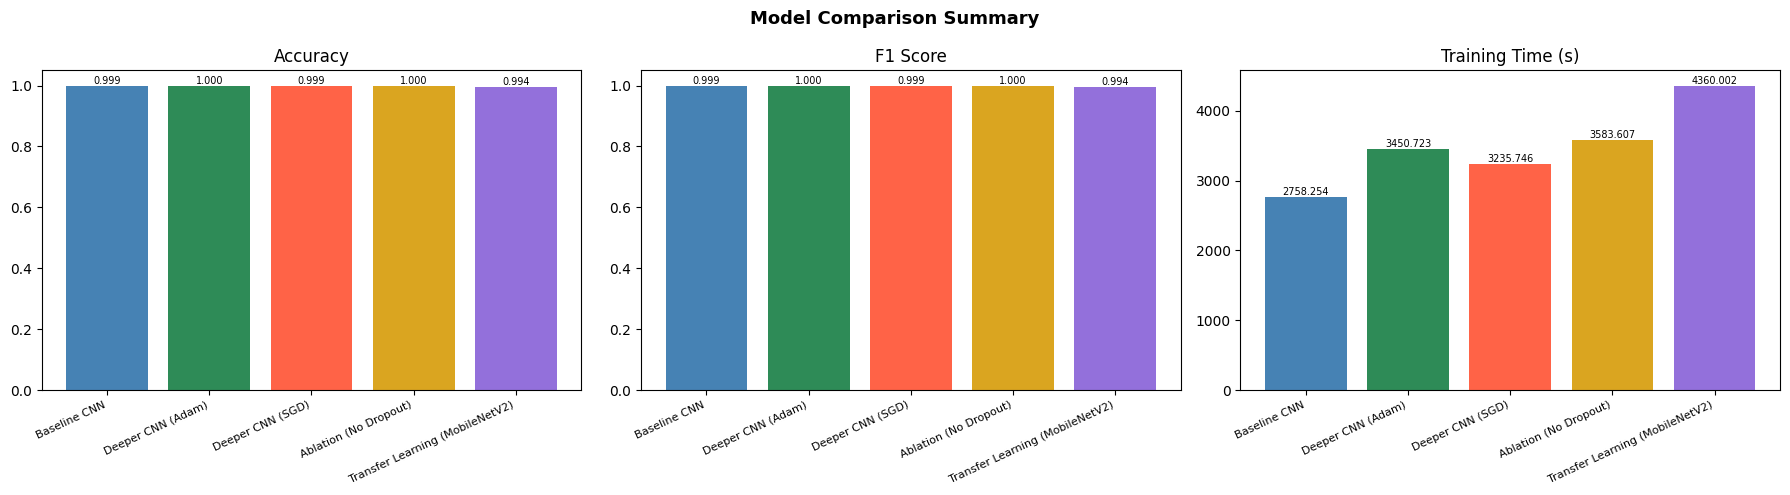

Saved: /content/drive/MyDrive/traffic_sign_outputs/model_comparison_bar.png
Saved: /content/drive/MyDrive/traffic_sign_outputs/assignment_summary.json


In [38]:
comparison_df = pd.DataFrame([
    {"Model": "Baseline CNN",
     "Loss": baseline_metrics["loss"], "Accuracy": baseline_metrics["accuracy"],
     "Precision": baseline_metrics["precision"], "Recall": baseline_metrics["recall"],
     "F1 Score": baseline_metrics["f1_score"],
     "Training Time (s)": baseline_metrics["training_time_seconds"]},
    {"Model": "Deeper CNN (Adam)",
     "Loss": deeper_metrics["loss"], "Accuracy": deeper_metrics["accuracy"],
     "Precision": deeper_metrics["precision"], "Recall": deeper_metrics["recall"],
     "F1 Score": deeper_metrics["f1_score"],
     "Training Time (s)": deeper_metrics["training_time_seconds"]},
    {"Model": "Deeper CNN (SGD)",
     "Loss": deeper_sgd_metrics["loss"], "Accuracy": deeper_sgd_metrics["accuracy"],
     "Precision": deeper_sgd_metrics["precision"], "Recall": deeper_sgd_metrics["recall"],
     "F1 Score": deeper_sgd_metrics["f1_score"],
     "Training Time (s)": deeper_sgd_metrics["training_time_seconds"]},
    {"Model": "Ablation (No Dropout)",
     "Loss": ablation_metrics["loss"], "Accuracy": ablation_metrics["accuracy"],
     "Precision": ablation_metrics["precision"], "Recall": ablation_metrics["recall"],
     "F1 Score": ablation_metrics["f1_score"],
     "Training Time (s)": ablation_metrics["training_time_seconds"]},
    {"Model": "Transfer Learning (MobileNetV2)",
     "Loss": transfer_metrics["loss"], "Accuracy": transfer_metrics["accuracy"],
     "Precision": transfer_metrics["precision"], "Recall": transfer_metrics["recall"],
     "F1 Score": transfer_metrics["f1_score"],
     "Training Time (s)": transfer_metrics["training_time_seconds"]},
])

display(comparison_df.round(4))
comparison_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["steelblue", "seagreen", "tomato", "goldenrod", "mediumpurple"]
for ax, metric in zip(axes, ["Accuracy", "F1 Score", "Training Time (s)"]):
    bars = ax.bar(comparison_df["Model"], comparison_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(comparison_df["Model"], rotation=25, ha="right", fontsize=8)
    ax.bar_label(bars, fmt="%.3f", fontsize=7)
plt.suptitle("Model Comparison Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
bar_path = os.path.join(OUTPUT_DIR, "model_comparison_bar.png")
plt.savefig(bar_path, dpi=200); plt.show(); print("Saved:", bar_path)

summary = {
    "dataset_root": DATASET_ROOT, "num_classes": len(class_names),
    "train_images": len(train_df), "validation_images": len(val_split_df),
    "flat_test_images": len(test_df),
    "invalid_train_images_skipped": len(invalid_train_files),
    "invalid_test_images_skipped":  len(invalid_test_files),
    "class_weights": class_weights,
    "models": {
        "baseline":            baseline_metrics,
        "deeper_adam":         deeper_metrics,
        "deeper_sgd":          deeper_sgd_metrics,
        "ablation_no_dropout": ablation_metrics,
        "transfer_learning":   transfer_metrics,
    },
}
summary_path = os.path.join(OUTPUT_DIR, "assignment_summary.json")
with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
print("Saved:", summary_path)
